# Intro (libraries, parameters)

In [232]:
### Import Modules
from qiskit.visualization import circuit_drawer
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import RYGate, UnitaryGate
from qiskit.quantum_info import Statevector
import numpy as np
import math

## Parameters

In [233]:
### Parameters (4,2,16) (3,1,8)
n = 3 # Number of qubits for |j⟩
# Be careful, we will encode, for now, having 1 neighbor with |k⟩=|0⟩, and having 2 neighbors as |k⟩=|1⟩
m = 1  # Number of qubits for |k⟩ (m << n)
# Be careful: if P =/= 2**p (and even =/= 2**n), issues may arise
P = 8 # Scaling factor (float * P = int)

In [234]:
### Network characteristics
N = 2**n  # Number of nodes
s = 2**m  # Sparsity level

### Adjacency matrix
A = np.zeros((N, N), dtype=int)

### Matrix option 1: random with less or equal to s neighbors

# np.random.seed(42)  # For reproducibility
# for i in range(N):
#     neighbors = np.random.choice(np.delete(np.arange(N), i), size=min(s, N-1), replace=False)
#     A[i, neighbors] = 1
# A[-1, :] = 0  # Force the last node to have no neighbors
# A = np.minimum(A, A.T)  # Ensure symmetry

### E structure (like an edge list)
# E_list = [np.nonzero(row)[0].tolist() for row in A]
# neighbors = [E_list[v] + [N-1] * (s - len(E_list[v])) for v in range(N)] # Fill missing neighbors with N-1 (last node)
# print("\nE_list: ", E_list)
# print("\nneighbors: ", neighbors)

## Matrix Option 2 (currently used)

In [235]:
#### Matrix Option 2: Circulant graph (subtype of Cayley graph) is defined by a set of shift operations that dictate node connection in a cyclic manner 

E_list = []
shifts = [1, -1]  # Node is connect to the previous and next one
if s > 2: # For s=4, shifts = [1, 2, -1, -2]
    shifts = list(range(1, s//2 + 1)) + [-i for i in range(1, s//2 + 1)]
for i in range(N):
    neighbors = []
    for shift in shifts:
        j = (i + shift) % N  # Wrap around (cycle structure)
        neighbors.append(j)
        A[i, j] = 1
        A[j, i] = 1  # Ensure symmetry
    # Attention: this is working for the case where s=2
    E_list.append(neighbors) # E_list.append([neighbors[-1], neighbors[0]])

### E structure (like an edge list)
neighbors = E_list

In [236]:
print("\nE_list: ", E_list)
print("\nneighbors: ", neighbors)

print("\n -------------------------------------------------------------------------------\n")
print("\nAdjacency Matrix (Sparse): \n", A)

### Neighbors 'inverse' (for O_L 'inverse')
neighbors_inverse = [[] for _ in range(N)]
for u, neighbors_u in enumerate(neighbors):
    for l, v in enumerate(neighbors_u):  
        neighbors_inverse[v].append(u)  # Append u directly
for v in range(N): # Reorder each list to match the original neighbor order
    neighbors_inverse[v] = sorted(neighbors_inverse[v], key=lambda x: neighbors[x].index(v))
print("\nNeighbors inverse:\n", neighbors_inverse)

### K (degree of each node)
K = [len(e) for e in E_list]
print("\nK: ", K)

### Feature vector
p = int(np.ceil(np.log2(P))) # Number of qubits for |x⟩
# Be careful: if the features are not these, issues may arise
# In particular, if features[N] is not 0, oracle O_L shall be adjusted
features = np.round(np.linspace(1 - 1/P, 0, N), 10)
print("\nFeature Vector: ", features)
print("\nFeature Vector (scaled by P): \n", features*P)


E_list:  [[1, 7], [2, 0], [3, 1], [4, 2], [5, 3], [6, 4], [7, 5], [0, 6]]

neighbors:  [[1, 7], [2, 0], [3, 1], [4, 2], [5, 3], [6, 4], [7, 5], [0, 6]]

 -------------------------------------------------------------------------------


Adjacency Matrix (Sparse): 
 [[0 1 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0]
 [0 1 0 1 0 0 0 0]
 [0 0 1 0 1 0 0 0]
 [0 0 0 1 0 1 0 0]
 [0 0 0 0 1 0 1 0]
 [0 0 0 0 0 1 0 1]
 [1 0 0 0 0 0 1 0]]

Neighbors inverse:
 [[7, 1], [0, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5, 7], [6, 0]]

K:  [2, 2, 2, 2, 2, 2, 2, 2]

Feature Vector:  [0.875 0.75  0.625 0.5   0.375 0.25  0.125 0.   ]

Feature Vector (scaled by P): 
 [7. 6. 5. 4. 3. 2. 1. 0.]


## Functions for binary conversion (f_x_binary and inverse)

In [237]:
def f_x_binary(float):
    ''' Multiply by the scaling factor (should be integer, and int forces that)
        Convert to p-bit binary representation
        Slicing [2:] removes the '0b' prefix
        zfill(p) ensures exactly p bits (pad with 0s if needed).'''
    return bin(int(float * P))[2:].zfill(p) 

def f_x_binary_inverse(binary, P):
    """ Decode a binary value in qr_z_state to its floating-point representation.
        qr_z_state is a string representing the binary state of qr_z."""
    return int(binary, 2) / P

def check_f_x_binary(vec, P):
    ''' Check if the functions f_x_binary and f_x_binary_inverse are working properly.'''
    vec_bin = [f_x_binary(x) for x in vec]
    vec_bin_inv = [f_x_binary_inverse(x_bin, P) for x_bin in vec_bin]
    # print("features: ", vec), print("f_x_binary: ", vec_bin), print("f_x_binary_inverse: ", vec_bin_inv)
    # Check if all elements match
    all_match = all(np.isclose(vec[i], vec_bin_inv[i]) for i in range(len(vec)))
    print("\nDo all elements (between vec and vec_bin_inv) match? ", "Yes" if all_match else "No")
    if not all_match:
        for i in range(len(vec)):
            if not np.isclose(vec[i], vec_bin_inv[i]):
                print(f"Mismatch at index {i}: Original = {vec[i]}, Decoded = {vec_bin_inv[i]}")

# Simulation

In [238]:
def access_statevector(qc, flag_a=False, flag_l=True):
    ''' If flag=True, shows all substates, including non-zero qubits. '''
    # Generates the quantum statevector resulting from executing the quantum circuit qc
    statevector = Statevector.from_instruction(qc)

    # Get the "useful" states
    num_qubits = qc.num_qubits
    useful_states = []
    for idx, amplitude in enumerate(statevector):
        if not np.isclose(amplitude, 0):
            state_bin = bin(idx)[2:].zfill(num_qubits)

            # Check if state meets the required criteria
            if (flag_a or (state_bin[0] == '0' and state_bin[1] == '0')) and \
               (flag_l or (state_bin[-1] == '0')): # and state_bin[-2] == '0')): # Attention: depends on the sparsity s!
                useful_states.append((state_bin, amplitude))

    # Extracted information from the states
    info_states = []
    for state_bin, amplitude in useful_states:#[-4:]: # Change
        info_states.append({
            'state_bin': state_bin,
            'amplitude': amplitude,
            'u': int(state_bin[2 + p + m + n: 2 + p + m + 2*n], 2), 
            'v': int(state_bin[2 + p + m : 2 + p + m + n], 2), 
            'k_v': int(state_bin[2 + p : 2 + p + m], 2), 
            'x_v': f_x_binary_inverse(state_bin[2 : 2 + p], P)
        })

    # Display
    print("\nExtracted Information from Useful States:")
    for state_info in info_states:
        print(f"State: |{state_info['state_bin']}>, Amplitude: {state_info['amplitude']}, "
            f"v: {state_info['v']}, x_v: {state_info['x_v']}, k_v: {state_info['k_v']}, u: {state_info['u']}")

    '''
    Remember we had:

    qr_l = QuantumRegister(m, 'l')  # Basis-encode non-zero entries of each row of A
    qr_u = QuantumRegister(n, 'u')  # Basis-encode node's l-neighbor index
    qr_v = QuantumRegister(n, 'v')  # Basis-encode node index
    qr_k = QuantumRegister(m, 'k')  # Basis-encode degree value (k)
    qr_z = QuantumRegister(p, 'z')  # Basis-encode feature value (x)
    qr_a1 = QuantumRegister(1, 'a1')  # Ancilla qubit for rotation (feature value)
    qr_a2 = QuantumRegister(1, 'a2')  # Ancilla qubit for rotation (degree inverse)

    qc = QuantumCircuit(qr_l, qr_u, qr_u, qr_k, qr_z, qr_a1, qr_a2)

    state_bin: |000000001111000000> = 00 1001 0000 00 1111 0000 00 = a2 a1 [qr_z][qr_k][q_v][q_u][qr_l]

    '''

# Quantum Circuit

## 0. Quantum registers

In [239]:
################################### 0. Quantum registers ####################################

qr_l = QuantumRegister(m, 'l')  # Basis-encode non-zero entries of each row of A
qr_u = QuantumRegister(n, 'u')  # Basis-encode node's l-neighbor index
qr_v = QuantumRegister(n, 'v')  # Basis-encode node index
qr_k = QuantumRegister(m, 'k')  # Basis-encode degree value (k)
qr_z = QuantumRegister(p, 'z')  # Basis-encode feature value (x)
qr_a1 = QuantumRegister(1, 'a1')  # Ancilla qubit for rotation (feature value)
qr_a2 = QuantumRegister(1, 'a2')  # Ancilla qubit for rotation (degree inverse)

########### 1. Create the quantum circuit (Start with all qubits initialized to |0⟩) #########

qc = QuantumCircuit(qr_l, qr_u, qr_v, qr_k, qr_z, qr_a1, qr_a2)
print("\n1. Initial:"), access_statevector(qc)

########## 2. Apply Hadamard gates to the `qr_v` qubits to create superposition #############

qc.h(qr_v)
print("\n2. Superposition of 'q_v' qubits:"), access_statevector(qc)


1. Initial:

Extracted Information from Useful States:
State: |0000000000000>, Amplitude: (1+0j), v: 0, x_v: 0.0, k_v: 0, u: 0

2. Superposition of 'q_v' qubits:

Extracted Information from Useful States:
State: |0000000000000>, Amplitude: (0.3535533905932737+0j), v: 0, x_v: 0.0, k_v: 0, u: 0
State: |0000000010000>, Amplitude: (0.3535533905932737+0j), v: 1, x_v: 0.0, k_v: 0, u: 0
State: |0000000100000>, Amplitude: (0.3535533905932737+0j), v: 2, x_v: 0.0, k_v: 0, u: 0
State: |0000000110000>, Amplitude: (0.3535533905932737+0j), v: 3, x_v: 0.0, k_v: 0, u: 0
State: |0000001000000>, Amplitude: (0.3535533905932737+0j), v: 4, x_v: 0.0, k_v: 0, u: 0
State: |0000001010000>, Amplitude: (0.3535533905932737+0j), v: 5, x_v: 0.0, k_v: 0, u: 0
State: |0000001100000>, Amplitude: (0.3535533905932737+0j), v: 6, x_v: 0.0, k_v: 0, u: 0
State: |0000001110000>, Amplitude: (0.3535533905932737+0j), v: 7, x_v: 0.0, k_v: 0, u: 0


(None, None)

## 3. Apply oracle O_X (I'm jumping this now)

In [240]:
#################################### 3. Apply oracle O_X ####################################

# def oracle_O_X(qc, qr_v, qr_z, features, N):
#     """ Apply the oracle O_X to entangle qr_v (v node index) and qr_z (encode x)."""
#     bin_v = [bin(v)[2:].zfill(len(qr_v)) for v in range(N)] 
#     bin_x = [f_x_binary(features[v]) for v in range(N)]
#     print(""), [print(v, bin_v[v], features[v], bin_x[v]) for v in range(N)]

#     for v in range(N): # Doing [j] instead of [-j-1], after 0, it's doing 8 (1000), not 1
#         #print(f"\nProcessing v={v} with bin_x[v] = {bin_x[v]} and bin_v[v] = {bin_v[v]}")
#         # Flip necessary qubits in qr_v where needed
#         [qc.x(qr_v[j]) for j, b in enumerate(bin_v[v]) if b == '0']
#         #print(f"\nStatevector after applying X on qr_v for v={v}:"), access_statevector(qc)

#         # Apply MCX gates where x_v[i] is 1
#         [qc.mcx(qr_v, qr_z[i]) for i, x in enumerate(bin_x[v]) if x == '1']
#         #print(f"\nStatevector after MCX on qr_z for v={v}:"), access_statevector(qc)

#         # Restore flipped qubits in qr_v
#         [qc.x(qr_v[j]) for j, b in enumerate(bin_v[v]) if b == '0']
#         #print(f"\nStatevector after applying oracle O_X for v={v}:"), access_statevector(qc)

#     return qc
        
# qc = oracle_O_X(qc, qr_v, qr_z, features, N)
# print("\n3. Apply oracle O_X:"), access_statevector(qc)
#print(""), [print(v, 1/math.sqrt(N)) for v in range(N)]

## 4. Controlled Rotation of Ancilla a1 by F_X (I'm jumping this now)

In [241]:
######################## 4. Controlled Rotation of Ancilla a1 by F_X ########################

def F_X(P):
    ''' Controlled rotation of one qubit based on a p-qubits register.
        We only need to know P (scaling factor) to create this unitary gate. '''
    thetas = [float(2 * np.arccos(x_int / P)) for x_int in range(P)] # turn x_int into x from features
    print("\nThetas (F_X): ", thetas)
    unitary = np.eye(2 * P, dtype=complex)  # Identity matrix of size 2P

    for x, theta in enumerate(thetas):
        W = np.array([
            [np.cos(theta / 2), -np.sin(theta / 2)],
            [np.sin(theta / 2), np.cos(theta / 2)]
        ])
        id = 2 * x  # Pair of rows/cols for each x
        unitary[id:(id + 2), id:(id + 2)] = W
        '''
            Building the unitary like this leads to having:
            x_v values in elements [v*2, v*2] 
            (instead of [v,v])
            That is why we apply on [qr_a1] + qr_z[:]
            (instead of qr_z[:] + [qr_a1])
        '''

    return UnitaryGate(unitary, label=f'F_X(P={P})')

# Append adds gates (or operations) to the quantum registers already defined
# qc.append(F_X(P), [qr_a1] + qr_z[:])
# print("\n4. Apply F_X:"), access_statevector(qc)
# print("\nExpected amplitudes (x_v normalized):"), [print(v, features[v], features[v]/math.sqrt(N)) for v in range(N)]

## 5. Superposition of the l-register qubits

In [242]:
############################ 5. Superposition of the l-register qubits ###########################

qc.h(qr_l)
print("\n5. Superposition of 'q_l' qubits:"), access_statevector(qc)
#print("\nExpected amplitudes (x_v normalized):"), [print(v, features[v]/math.sqrt(N*s)) for v in range(N)]
print("\nExpected amplitudes (x_v normalized):"), [print(v, 1/math.sqrt(N*s)) for v in range(N)]


5. Superposition of 'q_l' qubits:

Extracted Information from Useful States:
State: |0000000000000>, Amplitude: (0.24999999999999992+0j), v: 0, x_v: 0.0, k_v: 0, u: 0
State: |0000000000001>, Amplitude: (0.24999999999999992+0j), v: 0, x_v: 0.0, k_v: 0, u: 0
State: |0000000010000>, Amplitude: (0.24999999999999992+0j), v: 1, x_v: 0.0, k_v: 0, u: 0
State: |0000000010001>, Amplitude: (0.24999999999999992+0j), v: 1, x_v: 0.0, k_v: 0, u: 0
State: |0000000100000>, Amplitude: (0.24999999999999992+0j), v: 2, x_v: 0.0, k_v: 0, u: 0
State: |0000000100001>, Amplitude: (0.24999999999999992+0j), v: 2, x_v: 0.0, k_v: 0, u: 0
State: |0000000110000>, Amplitude: (0.24999999999999992+0j), v: 3, x_v: 0.0, k_v: 0, u: 0
State: |0000000110001>, Amplitude: (0.24999999999999992+0j), v: 3, x_v: 0.0, k_v: 0, u: 0
State: |0000001000000>, Amplitude: (0.24999999999999992+0j), v: 4, x_v: 0.0, k_v: 0, u: 0
State: |0000001000001>, Amplitude: (0.24999999999999992+0j), v: 4, x_v: 0.0, k_v: 0, u: 0
State: |0000001010000>

(None, [None, None, None, None, None, None, None, None])

## 6. Apply oracle O_L

In [243]:
#################################### 6. Apply oracle O_L #########################################

def f_int_binary(int, b):
    ''' Convert int to b-bit binary representation
        Slicing [2:] removes the '0b' prefix
        zfill(b) ensures exactly b bits (pad with 0s if needed).'''
    #return bin(int)[2:].zfill(b) 
    return format(int, f'0{b}b')

def oracle_O_L(qc, qr_l, qr_v, qr_u, neighbors, s, N):
    """ Apply the oracle O_L to entangle qr_l (l index) and qr_v (encode r(v,l)). """
    
    bin_l = [bin(l)[2:].zfill(len(qr_l)) for l in range(s)] 
    bin_v = [bin(v)[2:].zfill(len(qr_v)) for v in range(N)] 
    print("\n Neighbors: ", neighbors)

    ### Try to do these calculations with matrices on Mathematica (before-hand)
    ### THIS IS (NOW) WORKING AS EXPECTED 
    ### Salvou-me o reversed no controlo em bin_v e no encoding de bin_u?
    
    # Apply multi-controlled X gates based on neighbors
    for v in range(N):        
        #print(f"\nProcessing v={v}...")
        # Reason: Just like we control in qr_l, we also do in qr_v
        [qc.x(qr_v[j]) for j, b in enumerate(reversed(bin_v[v])) if b == '0']
        
        for l in range(s):
            # Flip necessary qubits in qr_l where needed
            [qc.x(qr_l[j]) for j, b in enumerate(reversed(bin_l[l])) if b == '0']
            #print(f"\nStatevector after flipping qr_l and qr_v for v={v}, l={l}:"), access_statevector(qc)

            bin_u = f_int_binary(neighbors[v][l], len(qr_v))
            #print(f"  Processing v={v}, neighbors[v={v}][l={l}] = {neighbors[v][l]}, bin_u = {bin_u}")

            # Apply MCX gates where qubit_i is '1'
            # Update/Main difference here: qc.mcx(qr_l, qr_v[i]) -> qc.mcx(qr_l, qr_u[i])
            # Because I want to use the already-existing mcx
            [qc.mcx(qr_v[:] + qr_l[:], qr_u[i]) for i, qubit_i in enumerate(reversed(bin_u)) if qubit_i == '1']
            #print(f"    Applied MCX gates for l={l}")

            # Restore flipped qubits in qr_l
            [qc.x(qr_l[j]) for j, b in enumerate(reversed(bin_l[l])) if b == '0']
            #print(f"\nStatevector after restoring qr_l and qr_v for v={v}, l={l}:"), access_statevector(qc)

        # Restore flipped qubits in qr_v
        [qc.x(qr_v[j]) for j, b in enumerate(reversed(bin_v[v])) if b == '0']

    return qc

qc = oracle_O_L(qc, qr_l, qr_v, qr_u, neighbors, s, N)
print("\n6. Apply oracle O_L:"), access_statevector(qc)
#print("\nExpected amplitudes:", *[f"k_{i+1}(v={N-v-1}) = {neighbors[N-v-1][i]} | {features[N-v-1]/math.sqrt(N*s)}" for v in range(N) for i in range(s)], sep='\n')
#print("\n", ",".join(f" k({v+1})={K[v]}" for v in range(N)))
#print("\nAdjacency Matrix (Sparse): \n", A)

print("\nExpected amplitudes (x_v normalized):"), [print(v, 1/math.sqrt(N*s)) for v in range(N)]


 Neighbors:  [[1, 7], [2, 0], [3, 1], [4, 2], [5, 3], [6, 4], [7, 5], [0, 6]]

6. Apply oracle O_L:

Extracted Information from Useful States:
State: |0000000000010>, Amplitude: (0.24999999999999767+1.57166790702227e-15j), v: 0, x_v: 0.0, k_v: 0, u: 1
State: |0000000001111>, Amplitude: (0.24999999999999764+1.588131007396334e-15j), v: 0, x_v: 0.0, k_v: 0, u: 7
State: |0000000010001>, Amplitude: (0.24999999999999745+1.3796946189529576e-15j), v: 1, x_v: 0.0, k_v: 0, u: 0
State: |0000000010100>, Amplitude: (0.2499999999999977+1.353863473673312e-15j), v: 1, x_v: 0.0, k_v: 0, u: 2
State: |0000000100011>, Amplitude: (0.2499999999999975+1.571997530550992e-15j), v: 2, x_v: 0.0, k_v: 0, u: 1
State: |0000000100110>, Amplitude: (0.2499999999999974+1.591772514607753e-15j), v: 2, x_v: 0.0, k_v: 0, u: 3
State: |0000000110101>, Amplitude: (0.2499999999999975+1.4608321519695695e-15j), v: 3, x_v: 0.0, k_v: 0, u: 2
State: |0000000111000>, Amplitude: (0.24999999999999742+1.5832723890943833e-15j), v: 3, x

(None, [None, None, None, None, None, None, None, None])

## After 6. Apply oracle O_X and Controlled Rotation of Ancilla a1 by F_X (moved here)

In [244]:
################################### 3. Apply oracle O_X ####################################

def oracle_O_X(qc, qr_u, qr_z, features, N):
    """ Apply the oracle O_X to entangle qr_u (u node index) and qr_z (encode x)."""
    bin_u = [bin(u)[2:].zfill(len(qr_u)) for u in range(N)] 
    bin_x = [f_x_binary(features[u]) for u in range(N)]
    print(""), [print(u, bin_u[u], features[u], bin_x[u]) for u in range(N)]

    for u in range(N): # Doing [j] instead of [-j-1], after 0, it's doing 8 (1000), not 1
        [qc.x(qr_u[j]) for j, b in enumerate(bin_u[u]) if b == '0']

        # Apply MCX gates where x_u[i] is 1
        [qc.mcx(qr_u, qr_z[i]) for i, x in enumerate(bin_x[u]) if x == '1']

        # Restore flipped qubits in qr_u
        [qc.x(qr_u[j]) for j, b in enumerate(bin_u[u]) if b == '0']

    return qc
        
qc = oracle_O_X(qc, qr_u, qr_z, features, N)
print("\nAfter 6: 1. Apply oracle O_X to qr_u, qr_z:"), access_statevector(qc)
print("\nExpected amplitudes (x_u normalized):"), [print(u, 1/math.sqrt(N*s)) for u in range(N)]

# Append adds gates (or operations) to the quantum registers already defined
qc.append(F_X(P), [qr_a1] + qr_z[:])
print("\nAfter 6. 2: Apply F_X:"), access_statevector(qc)
print("\nExpected amplitudes (x_u normalized):"), [print(u, features[u], features[u]/math.sqrt(N*s)) for u in range(N)]


0 000 0.875 111
1 001 0.75 110
2 010 0.625 101
3 011 0.5 100
4 100 0.375 011
5 101 0.25 010
6 110 0.125 001
7 111 0.0 000

After 6: 1. Apply oracle O_X to qr_u, qr_z:

Extracted Information from Useful States:
State: |0000000001111>, Amplitude: (0.24999999999999736+1.5357466861500673e-15j), v: 0, x_v: 0.0, k_v: 0, u: 7
State: |0000001101110>, Amplitude: (0.24999999999999684+1.2217281944133123e-15j), v: 6, x_v: 0.0, k_v: 0, u: 7
State: |0000101011100>, Amplitude: (0.24999999999999695+1.4376159074823315e-15j), v: 5, x_v: 0.125, k_v: 0, u: 6
State: |0000101111101>, Amplitude: (0.24999999999999709+1.3394851288145954e-15j), v: 7, x_v: 0.125, k_v: 0, u: 6
State: |0001001001010>, Amplitude: (0.24999999999999703+1.3542047456147559e-15j), v: 4, x_v: 0.25, k_v: 0, u: 5
State: |0001001101011>, Amplitude: (0.24999999999999686+1.4376159074823313e-15j), v: 6, x_v: 0.25, k_v: 0, u: 5
State: |0001100111000>, Amplitude: (0.2499999999999968+1.5087607220164399e-15j), v: 3, x_v: 0.375, k_v: 0, u: 4
State

(None, [None, None, None, None, None, None, None, None])

## Intermediate (reset qr_x, qr_u)

In [245]:

########################################### Intermediate #########################################

# Put qr_z to zeros (do a good justification)
# qc = oracle_O_X(qc, qr_v, qr_z, features, N)
# print("\nIntermediate 0. Reapply oracle O_X:"), access_statevector(qc)

# def swap_registers(qc, qr_u, qr_v):
#     """ Perform the swap of quantum registers qr_u and qr_v. """
    
#     n = len(qr_u)
    
#     for i in range(n):
#         qc.cx(qr_u[i], qr_v[i]) 
#         qc.cx(qr_v[i], qr_u[i]) 
#         qc.cx(qr_u[i], qr_v[i])  

#     return qc

# qc = swap_registers(qc, qr_u, qr_v)
# print("\nIntermediate 1. Swap qr_v with qr_u:"), access_statevector(qc)

# def oracle_O_L_inverse(qc, qr_l, qr_v, qr_u, neighbors, s, N):
#     """ Apply the oracle O_L_inverse to put qr_u (v) to zeros, based to qr_l and qr_v (r(v,l)). """
    
#     bin_l = [bin(l)[2:].zfill(len(qr_l)) for l in range(s)] 
#     bin_v = [bin(v)[2:].zfill(len(qr_v)) for v in range(N)] 
#     print("\n Neighbors: ", neighbors)
#     print("\n Neighbors Inverse: ", neighbors_inverse)

#     # Apply multi-controlled X gates based on neighbors
#     for v in range(N):        
#         [qc.x(qr_v[j]) for j, b in enumerate(reversed(bin_v[v])) if b == '0']
        
#         for l in range(s):
#             # Flip necessary qubits in qr_l where needed
#             [qc.x(qr_l[j]) for j, b in enumerate(reversed(bin_l[l])) if b == '0']

#             # focus -- bin_u is v for which r(v,l) is encoded in qr_v
#             bin_u = f_int_binary(neighbors_inverse[v][l], len(qr_v))

#             [qc.mcx(qr_v[:] + qr_l[:], qr_u[i]) for i, qubit_i in enumerate(reversed(bin_u)) if qubit_i == '1']

#             # Restore flipped qubits in qr_l
#             [qc.x(qr_l[j]) for j, b in enumerate(reversed(bin_l[l])) if b == '0']

#         # Restore flipped qubits in qr_v
#         [qc.x(qr_v[j]) for j, b in enumerate(reversed(bin_v[v])) if b == '0']

#     return qc

# qc = oracle_O_L_inverse(qc, qr_l, qr_v, qr_u, neighbors, s, N)
# print("\nIntermediate 2. 'Reset' qr_u:"), access_statevector(qc)

In [246]:
########################################### Intermediate #########################################

# Put qr_z to zeros (this is new)
qc = oracle_O_X(qc, qr_u, qr_z, features, N)
print("\nIntermediate 0. Reapply oracle O_X:"), access_statevector(qc)

qc = oracle_O_L(qc, qr_l, qr_v, qr_u, neighbors, s, N)
print("\nIntermediate 2. 'Reset' qr_u:"), access_statevector(qc)


0 000 0.875 111
1 001 0.75 110
2 010 0.625 101
3 011 0.5 100
4 100 0.375 011
5 101 0.25 010
6 110 0.125 001
7 111 0.0 000

Intermediate 0. Reapply oracle O_X:

Extracted Information from Useful States:
State: |0000000000010>, Amplitude: (0.1874999999999972+1.1775693440128311e-15j), v: 0, x_v: 0.0, k_v: 0, u: 1
State: |0000000010001>, Amplitude: (0.21874999999999684+1.182475882946218e-15j), v: 1, x_v: 0.0, k_v: 0, u: 0
State: |0000000010100>, Amplitude: (0.156249999999998+7.408873789414063e-16j), v: 1, x_v: 0.0, k_v: 0, u: 2
State: |0000000100011>, Amplitude: (0.18749999999999717+1.25607396694702e-15j), v: 2, x_v: 0.0, k_v: 0, u: 1
State: |0000000100110>, Amplitude: (0.12499999999999793+7.82592959875194e-16j), v: 2, x_v: 0.0, k_v: 0, u: 3
State: |0000000110101>, Amplitude: (0.1562499999999977+1.0205600981444537e-15j), v: 3, x_v: 0.0, k_v: 0, u: 2
State: |0000000111000>, Amplitude: (0.09374999999999847+5.801982288729886e-16j), v: 3, x_v: 0.0, k_v: 0, u: 4
State: |0000001000111>, Amplitu

(None, None)

## 7. Superposition of the l-register qubits (end block-encoding A)

In [247]:
############################ 7. Superposition of the l-register qubits ###########################

qc.h(qr_l)
print("\n7. Superposition of 'q_l' qubits:"), access_statevector(qc, flag_l=False)

### Checking the sum of neighbors-features for each node (3 and 4 have no neighbors)
from collections import defaultdict
neighbor_feature_sums = defaultdict(float)
expected_amplitudes = defaultdict(float)

for v in range(N):
    for neighbor in neighbors[v]:
        expected_amplitudes[neighbor] += features[v] / (s * math.sqrt(N))
        neighbor_feature_sums[neighbor] += features[v] / (s * math.sqrt(len(set(K)) * N)) # 2 comes from later using ancilla qubit

print("\nExpected amplitudes:", 
      *[f"node (v) = {u}, sum_features={expected_amplitudes[u]}" for u in sorted(expected_amplitudes)], sep='\n')


7. Superposition of 'q_l' qubits:

Extracted Information from Useful States:
State: |0000000000000>, Amplitude: (0.13258252147247424+1.5371377728574924e-15j), v: 0, x_v: 0.0, k_v: 0, u: 0
State: |0000000010000>, Amplitude: (0.26516504294494875+2.609595345558379e-15j), v: 1, x_v: 0.0, k_v: 0, u: 0
State: |0000000100000>, Amplitude: (0.22097086912078992+2.518571532081681e-15j), v: 2, x_v: 0.0, k_v: 0, u: 0
State: |0000000110000>, Amplitude: (0.176776695296632+2.0006788314003317e-15j), v: 3, x_v: 0.0, k_v: 0, u: 0
State: |0000001000000>, Amplitude: (0.13258252147247415+1.5065721968420335e-15j), v: 4, x_v: 0.0, k_v: 0, u: 0
State: |0000001010000>, Amplitude: (0.08838834764831609+1.0987041250639424e-15j), v: 5, x_v: 0.0, k_v: 0, u: 0
State: |0000001100000>, Amplitude: (0.04419417382415807+5.659359630155216e-16j), v: 6, x_v: 0.0, k_v: 0, u: 0
State: |0000001110000>, Amplitude: (0.17677669529663287+1.9209099924209308e-15j), v: 7, x_v: 0.0, k_v: 0, u: 0

Expected amplitudes:
node (v) = 0, sum

## 8. Apply oracle O_K

In [248]:
#################################### 8. Apply oracle O_K ####################################

def oracle_O_K(qc, qr_v, qr_k, K, N):
    """ Apply the oracle O_K to entangle qr_v (node index) and qr_k (encode k_v)."""
    bin_v = [bin(v)[2:].zfill(len(qr_v)) for v in range(N)] 

    for v in range(N): 

        if K[v] == 0:
            continue 
        # Notice: having 1 neighbor will lead to the same encoding as having 0 neighbors
        # Because: if a node has 0 neighbors, its index won't be encoded in qr_v register
        bin_k = format(K[v] - 1, f'0{len(qr_k)}b')
        
        # Flip necessary qubits in qr_v where needed
        [qc.x(qr_v[j]) for j, b in enumerate(bin_v[v]) if b == '0']

        # Apply MCX gates where k[i] is 1
        [qc.mcx(qr_v, qr_k[i]) for i, x in enumerate(bin_k) if x == '1']

        # Restore flipped qubits in qr_v
        [qc.x(qr_v[j]) for j, b in enumerate(bin_v[v]) if b == '0']

    return qc

qc = oracle_O_K(qc, qr_v, qr_k, K, N)
print("\n8. Apply oracle O_K (true degree = k_v + 1):"), access_statevector(qc, flag_a=True, flag_l=False)


8. Apply oracle O_K (true degree = k_v + 1):

Extracted Information from Useful States:
State: |0000010000000>, Amplitude: (0.132582521472474+1.5749989976171616e-15j), v: 0, x_v: 0.0, k_v: 1, u: 0
State: |0000010010000>, Amplitude: (0.2651650429449484+2.698596413362738e-15j), v: 1, x_v: 0.0, k_v: 1, u: 0
State: |0000010100000>, Amplitude: (0.2209708691207897+2.507241394960653e-15j), v: 2, x_v: 0.0, k_v: 1, u: 0
State: |0000010110000>, Amplitude: (0.17677669529663168+2.0165875016219733e-15j), v: 3, x_v: 0.0, k_v: 1, u: 0
State: |0000011000000>, Amplitude: (0.132582521472474+1.5112139914831335e-15j), v: 4, x_v: 0.0, k_v: 1, u: 0
State: |0000011010000>, Amplitude: (0.08838834764831592+1.121144146278883e-15j), v: 5, x_v: 0.0, k_v: 1, u: 0
State: |0000011100000>, Amplitude: (0.044194173824157995+5.581188036727481e-16j), v: 6, x_v: 0.0, k_v: 1, u: 0
State: |0000011110000>, Amplitude: (0.1767766952966326+1.8939240282873036e-15j), v: 7, x_v: 0.0, k_v: 1, u: 0
State: |0100010000000>, Amplitude

(None, None)

## 9. Controlled Rotation of Ancilla a1 by F_X

In [249]:
######################## 9. Controlled Rotation of Ancilla a1 by F_X ########################

def F_K_inv(s):
    ''' Controlled rotation of one qubit based on a m-qubits register.
        We only need to know s (sparsity level) to create this unitary gate.
        Note that having s=2 neighbors, qubit 0 means k=1, and qubit 1 means k=2'''
    # Avoid: float division by zero
    thetas = [
        np.pi if k_int == 0 else float(2 * np.arccos(1 / k_int)) 
        for k_int in range(1, s + 1)] # Important to match our encoding in qr_k
    print("\nThetas (F_K_inv): ", thetas)
    unitary = np.eye(2 * s, dtype=complex)  # Identity matrix of size 2s

    for k, theta in enumerate(thetas):
        W = np.array([
            [np.cos(theta / 2), -np.sin(theta / 2)],
            [np.sin(theta / 2), np.cos(theta / 2)]
        ])
        id = 2 * k  # Pair of rows/cols for each k
        unitary[id:(id + 2), id:(id + 2)] = W

    return UnitaryGate(unitary, label=f'F_K_inv(s={s})')

# Append adds gates (or operations) to the quantum registers already defined
qc.append(F_K_inv(s), qr_k[:] + [qr_a2])
print("\n9. Apply F_K_inv:"), access_statevector(qc, flag_a=False, flag_l=False)

### Checking the mean of neighbors-features for each node (3 and 4 have no neighbors)
feature_means = {
    v: (neighbor_feature_sums[v] #/ K[v]
        if K[v] > 0 else 0)
    for v in range(N)
}

print("\nMean:", *[f"node (v) = {node}, neighbors' features mean={mean}" for node, mean in feature_means.items()], sep='\n')


Thetas (F_K_inv):  [0.0, 2.0943951023931957]

9. Apply F_K_inv:

Extracted Information from Useful States:
State: |0000010000000>, Amplitude: (0.132582521472474+1.5749989976171616e-15j), v: 0, x_v: 0.0, k_v: 1, u: 0
State: |0000010010000>, Amplitude: (0.2651650429449484+2.698596413362738e-15j), v: 1, x_v: 0.0, k_v: 1, u: 0
State: |0000010100000>, Amplitude: (0.2209708691207897+2.507241394960653e-15j), v: 2, x_v: 0.0, k_v: 1, u: 0
State: |0000010110000>, Amplitude: (0.17677669529663168+2.0165875016219733e-15j), v: 3, x_v: 0.0, k_v: 1, u: 0
State: |0000011000000>, Amplitude: (0.132582521472474+1.5112139914831335e-15j), v: 4, x_v: 0.0, k_v: 1, u: 0
State: |0000011010000>, Amplitude: (0.08838834764831592+1.121144146278883e-15j), v: 5, x_v: 0.0, k_v: 1, u: 0
State: |0000011100000>, Amplitude: (0.044194173824157995+5.581188036727481e-16j), v: 6, x_v: 0.0, k_v: 1, u: 0
State: |0000011110000>, Amplitude: (0.1767766952966326+1.8939240282873036e-15j), v: 7, x_v: 0.0, k_v: 1, u: 0

Mean:
node (v

# Draw and Visualize


 -------------------------------------------------------------------------------



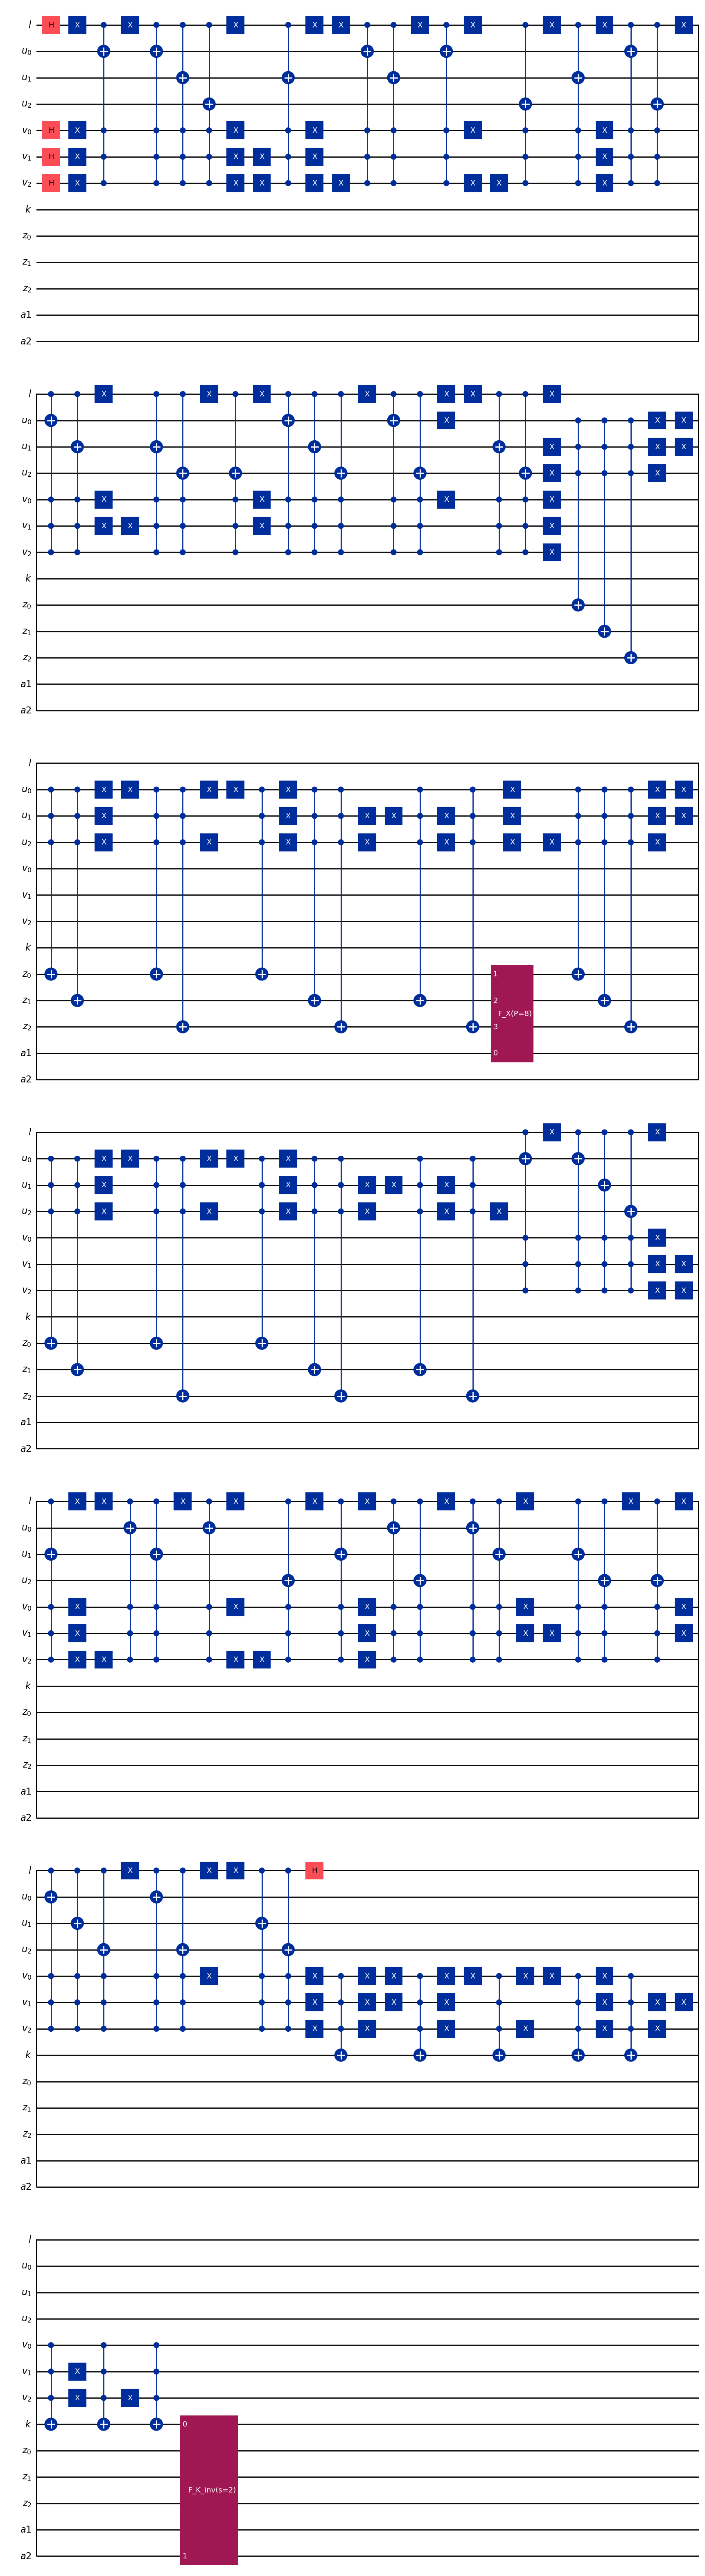

In [250]:
###################################### Draw and Visualize ########################################

print("\n -------------------------------------------------------------------------------\n")
circuit_drawer(qc, output='mpl', filename='network_circuit.png')
qc.draw(output='mpl', filename='network_circuit.png')